#Happy Learning!

## What Are We Building?

Imagine that we have a small knowledge base about AWS services.

A user asks:

> "Which AWS service should I use to decouple applications?"

Our system will:

1. Break documents into chunks.
2. Convert the chunks into embeddings.
3. Convert the question into an embedding.
4. Compare the question with every chunk.
5. Retrieve the most relevant chunks.

That is the **retrieval** part of Retrieval-Augmented Generation.

The architecture looks like this:

📄 Documents → ✂️ Chunks → 🔢 Embeddings → 🔍 Vector Search → 📚 Relevant Context → 📝 Prompt → 🤖 LLM → 💬 Answer

In a production application, you might use Pinecone, OpenSearch, pgvector, Qdrant, or another vector database.

For learning, we don't need any of them.

We will store our embeddings in memory and use cosine similarity.

## Step 1: Open Google Colab

Create a new Google Colab notebook.

Run:

In [ ]:
!pip install -q sentence-transformers openai rank_bm25 FlagEmbedding langchain langchain-text-splitters langchain-experimental

We will use the `sentence-transformers` library to generate embeddings.

No API key is required.

## Step 2: Create Our Knowledge Base

Let's create a tiny collection of documents.

In [ ]:
documents = [
    """
    Amazon S3 is an object storage service designed for storing
    and retrieving files. It provides high durability and is
    commonly used for backups, static websites, data lakes,
    and application assets.
    """,

    """
    Amazon SQS is a managed message queue service.

    It allows applications to communicate asynchronously.

    Producers send messages to a queue and consumers process
    those messages independently.

    SQS is commonly used to decouple distributed applications.
    """,

    """
    AWS Lambda is a serverless compute service.

    Developers upload code and AWS executes the code in response
    to events.

    Lambda automatically manages servers and scales applications
    based on incoming requests.
    """,

    """
    Amazon DynamoDB is a managed NoSQL database.

    It provides low-latency access to data and automatically
    scales to handle large workloads.
    """
]

Obviously, real RAG systems contain thousands or millions of documents.

But the mechanism is exactly the same.

## Step 3: Chunk the Documents

Why do we need chunks?

Because embedding an entire book or a 200-page PDF as one vector would produce a poor representation for individual questions.

Instead, RAG systems divide documents into smaller pieces.

Let's write a very simple chunker.

In [ ]:
documents[0]

'\n    Amazon S3 is an object storage service designed for storing\n    and retrieving files. It provides high durability and is\n    commonly used for backups, static websites, data lakes,\n    and application assets.\n    '

In [ ]:
def chunk_text(text, chunk_size=250):
    words = text.split()

    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)

    return chunks


chunks = []

for document in documents:
    chunks.extend(chunk_text(document))


print("Number of chunks:", len(chunks))

for index, chunk in enumerate(chunks):
    print(f"\nCHUNK {index}")
    print(chunk)

Number of chunks: 4

CHUNK 0
Amazon S3 is an object storage service designed for storing and retrieving files. It provides high durability and is commonly used for backups, static websites, data lakes, and application assets.

CHUNK 1
Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers process those messages independently. SQS is commonly used to decouple distributed applications.

CHUNK 2
AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages servers and scales applications based on incoming requests.

CHUNK 3
Amazon DynamoDB is a managed NoSQL database. It provides low-latency access to data and automatically scales to handle large workloads.


Production systems usually use more sophisticated strategies.

For example:

- token-based chunking
- overlapping chunks
- recursive text splitting
- semantic chunking

But our goal is to understand the mechanism first.

## Step 4: Generate Embeddings

Now we need to convert text into vectors.

We will use a small embedding model.

### Core Specifications

Dimensions: 384 output vector size

Parameters: Around 22 million

Max Tokens: 256 token sequence length.

File Size: Roughly 70 MB

Speed: Fast inference on CPU and edge devices

### Common Uses Semantic Search:

Find text with similar meanings instead of exact keyword matches.

Clustering: Group similar user reviews, support tickets, or articles together.

RAG Systems: Build local or lightweight retrieval-augmented generation pipelines.


In [ ]:
%%capture
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Now generate embeddings for our chunks.

In [ ]:
chunk_embeddings = embedding_model.encode(chunks)

print(chunk_embeddings.shape)

(4, 384)


You should see something similar to: (4, 384)


What does that mean?

We have four chunks.

Each chunk has been converted into a vector containing 384 numbers.

Something like this: [0.023, -0.041, 0.087, ...]

Humans cannot interpret these numbers directly.

But mathematically, texts with similar meanings tend to have vectors that are closer together.

That is what makes semantic search possible.

## Step 5: Ask a Question

Let's ask:

In [ ]:
question = "Which AWS service can help decouple applications?"

Convert the question into an embedding.

In [ ]:
question_embedding = embedding_model.encode([question])

Now we have:

Documents → Vectors

Question → Vector

We need to find which document vectors are closest to the question vector.

## Step 6: Perform Similarity Search

We will use cosine similarity.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(
    question_embedding,
    chunk_embeddings
)[0]

Let's inspect the results.

In [ ]:
for index, score in enumerate(scores):
    print(round(score, 3), chunks[index][:200])

0.437 Amazon S3 is an object storage service designed for storing and retrieving files. It provides high durability and is commonly used for backups, static websites, data lakes, and application assets.
0.467 Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers process those messages independently. SQS is commo
0.549 AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages servers and scales applications based on incoming reque
0.405 Amazon DynamoDB is a managed NoSQL database. It provides low-latency access to data and automatically scales to handle large workloads.


You should see the SQS document receive the highest similarity score.

Now retrieve the best chunk.

In [ ]:
best_chunk_index = scores.argmax()

retrieved_chunk = chunks[best_chunk_index]

print(retrieved_chunk)

AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages servers and scales applications based on incoming requests.


Congratulations.

You just built semantic retrieval.

This is the foundation of a RAG system.

## Let's Make It Reusable

Let's wrap everything into a function.

In [ ]:
def search(question, top_k=2):

    question_embedding = embedding_model.encode([question])

    scores = cosine_similarity(
        question_embedding,
        chunk_embeddings
    )[0]

    top_indices = scores.argsort()[::-1][:top_k]

    results = []

    for index, score in zip(top_indices, scores[top_indices]):
        results.append({
            "score": float(score),
            "text": chunks[index]
        })

    return results

Now try asking different questions.

In [ ]:
questions = [
    "Where should I store application files?",
    "How can I run code without managing servers?",
    "Which database provides low latency access?",
    "How can microservices communicate asynchronously?"
]

for question in questions:

    print("\nQUESTION:", question)

    results = search(question)

    for result in results:
        print(
            round(result["score"], 3),
            result["text"][:150]
        )


QUESTION: Where should I store application files?
0.229 Amazon S3 is an object storage service designed for storing and retrieving files. It provides high durability and is commonly used for backups, static
0.079 Amazon DynamoDB is a managed NoSQL database. It provides low-latency access to data and automatically scales to handle large workloads.

QUESTION: How can I run code without managing servers?
0.311 AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages serve
0.178 Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers 

QUESTION: Which database provides low latency access?
0.488 Amazon DynamoDB is a managed NoSQL database. It provides low-latency access to data and automatically scales to handle large workloads.
0.23 Amazon SQS is a managed message queue service. It allows applications to commu

You now have a tiny semantic search engine.
Yaaayee!

In [ ]:
def build_prompt(question, retrieved_chunks):

    context = "\n\n".join(retrieved_chunks)

    prompt = f"""
    Answer the question using only the context below.

    CONTEXT:

    {context}

    QUESTION:

    {question}
    """

    return prompt

Let's generate the prompt.

In [ ]:
question = "Which AWS service should I use to decouple applications?"

results = search(question)

retrieved_chunks = [
    result["text"]
    for result in results
]

prompt = build_prompt(
    question,
    retrieved_chunks
)

print(prompt)


    Answer the question using only the context below.

    CONTEXT:

    AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages servers and scales applications based on incoming requests.

Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers process those messages independently. SQS is commonly used to decouple distributed applications.

    QUESTION:

    Which AWS service should I use to decouple applications?
    


This prompt could now be sent to an LLM.


We will use openAI library to call llama 3.1-8B-instruct an 8B parameter model which is suitable for simple chatbot usecases. Although the library from openAI the service we use is nscale.

In [ ]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get('NSCALE_API'),
    base_url="https://inference.api.nscale.com/v1",
)

response = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
    ],
    max_tokens=500,
    temperature=0.7,
)

print(response.choices[0].message.content)


You should use Amazon SQS to decouple applications. It's a managed message queue service that allows applications to communicate asynchronously.


📄 Documents → ✂️ Chunks → 🔢 Embeddings → 🔍 Vector Search → 📚 Relevant Context → 📝 Prompt → 🤖 LLM → 💬 Answer

## Five Experiments You Should Try

Don't stop after running the notebook.

Change it.

First, add documents that use similar terminology.

For example:

SQS decouples applications.

EventBridge connects applications using events.

SNS distributes messages to multiple subscribers.

Does the correct document still rank first?

Second, change the chunk size.

Try:

In [ ]:
chunk_size = 50

Then:

In [ ]:
chunk_size = 500

What happens to retrieval quality?

Third, retrieve more documents.

Change:

In [ ]:
top_k = 1

to:

In [ ]:
top_k = 3

Would sending more context always produce a better answer?

Fourth, add irrelevant documents.

Does retrieval quality change?

Fifth, ask ambiguous questions.

For example:

Which service should I use for messaging?

Now you are starting to encounter the problems that real RAG systems must solve.


The LLM answers only using the context given (topK chunks), basic RAG alone cannot provide accurate chunks.

# Step 7: Keyword Search BM25


## What is BM25? It's a keyword based ranking algorithm (Best Matching 25 Algorithm)

## Core Components of BM25

- **Term Frequency (TF):** Measures how often a query word appears in a document. Repeated occurrences eventually have diminishing impact.
- **Inverse Document Frequency (IDF):** Gives higher scores to rare words and lower scores to common words.
- **Document Length Normalization:** Prevents longer documents from automatically scoring higher simply because they contain more words.


In [ ]:
from rank_bm25 import BM25Okapi

# Tokenize each chunk
tokenized_chunks = [
    chunk.lower().split()
    for chunk in chunks
]

# Create the BM25 index
bm25 = BM25Okapi(tokenized_chunks)

In [ ]:
def keyword_search(question, top_k=2):

    # Tokenize the question
    query_tokens = question.lower().split()

    # Calculate BM25 scores
    scores = bm25.get_scores(query_tokens)

    # Get the top-k chunks
    top_indices = scores.argsort()[::-1][:top_k]

    results = []

    for index in top_indices:
        results.append({
            "text": chunks[index],
            "bm25_score": float(scores[index])
        })

    return results

In [ ]:
question = "Which AWS service can help decouple applications?"

results = keyword_search(question, top_k=4)

for result in results:
    print(
        round(result["bm25_score"], 3),
        result["text"][:150]
    )

1.19 AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages serve
0.828 Amazon S3 is an object storage service designed for storing and retrieving files. It provides high durability and is commonly used for backups, static
0.78 Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers 
0.0 Amazon DynamoDB is a managed NoSQL database. It provides low-latency access to data and automatically scales to handle large workloads.


#STEP 8: Hybrid Search

                    Query
                      │
            ┌─────────┴─────────┐
            ↓                   ↓
     Semantic Search       Keyword Search
            │                   │
     Cosine Similarity        BM25
            │                   │
    Semantic Score          BM25 Score
            │                   │
            └─────────┬─────────┘
                      ↓
               Hybrid Search

In [ ]:
def hybrid_search(question, top_k=2, semantic_weight=0.5, keyword_weight=0.5):

    # -------------------------
    # 1. Semantic Search
    # -------------------------

    question_embedding = embedding_model.encode([question])

    semantic_scores = cosine_similarity(
        question_embedding,
        chunk_embeddings
    )[0]

    # -------------------------
    # 2. Keyword Search (BM25)
    # -------------------------

    query_tokens = question.lower().split()

    bm25_scores = bm25.get_scores(query_tokens)

    # -------------------------
    # 3. Normalize Scores
    # -------------------------

    semantic_normalized = (
        semantic_scores - semantic_scores.min()
    ) / (
        semantic_scores.max() - semantic_scores.min()
    )

    bm25_normalized = (
        bm25_scores - bm25_scores.min()
    ) / (
        bm25_scores.max() - bm25_scores.min()
    )

    # -------------------------
    # 4. Combine Scores
    # -------------------------

    hybrid_scores = (
        semantic_weight * semantic_normalized
        + keyword_weight * bm25_normalized
    )

    # -------------------------
    # 5. Get Top Results
    # -------------------------

    top_indices = hybrid_scores.argsort()[::-1][:top_k]

    results = []

    for index in top_indices:
        results.append({
            "text": chunks[index],
            "semantic_score": float(semantic_normalized[index]),
            "bm25_score": float(bm25_normalized[index]),
            "hybrid_score": float(hybrid_scores[index])
        })

    return results

In [ ]:
question = "Which AWS service can help decouple applications?"

results = hybrid_search(question, top_k=4)

for result in results:
    print(
        f"Hybrid: {result['hybrid_score']:.3f} | "
        f"Semantic: {result['semantic_score']:.3f} | "
        f"BM25: {result['bm25_score']:.3f}"
    )
    print(result["text"][:150])
    print()

Hybrid: 1.000 | Semantic: 1.000 | BM25: 1.000
AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages serve

Hybrid: 0.543 | Semantic: 0.431 | BM25: 0.655
Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers 

Hybrid: 0.460 | Semantic: 0.225 | BM25: 0.695
Amazon S3 is an object storage service designed for storing and retrieving files. It provides high durability and is commonly used for backups, static

Hybrid: 0.000 | Semantic: 0.000 | BM25: 0.000
Amazon DynamoDB is a managed NoSQL database. It provides low-latency access to data and automatically scales to handle large workloads.



let's change the dataset and see if hybrid works?

In [ ]:
documents = [
    """
    The application becomes unresponsive when users upload large files.
    The server runs out of memory during the upload process.
    """,

    """
    Users are unable to authenticate after enabling two-factor authentication.
    The login process fails with an invalid verification code error.
    """,

    """
    The API returns error code E403 when clients attempt to access protected
    resources. Check the API credentials and authorization permissions.
    """,

    """
    Database queries are taking several seconds to complete.
    Adding indexes to frequently queried columns can improve database performance.
    """,

    """
    The background worker stops processing jobs when the message queue
    contains a large number of pending tasks.
    """
]

In [ ]:
from rank_bm25 import BM25Okapi

def process_documents(documents, embedding_model, chunk_size=250):
    # Chunk the documents
    all_chunks = []
    for document in documents:
        all_chunks.extend(chunk_text(document, chunk_size))

    # Generate chunk embeddings
    chunk_embeddings = embedding_model.encode(all_chunks)

    # Tokenize chunks for BM25
    tokenized_chunks = [
        chunk.lower().split()
        for chunk in all_chunks
    ]
    bm25_index = BM25Okapi(tokenized_chunks)

    return all_chunks, chunk_embeddings, bm25_index

# Now, call the new function to process the current documents
chunks, chunk_embeddings, bm25 = process_documents(documents, embedding_model)

In [ ]:
question = "Why is the application running out of memory?"
results = hybrid_search(question, top_k=4)

for result in results:
    print(
        f"Hybrid: {result['hybrid_score']:.3f} | "
        f"Semantic: {result['semantic_score']:.3f} | "
        f"BM25: {result['bm25_score']:.3f}"
    )
    print(result["text"][:150])
    print()

Hybrid: 1.000 | Semantic: 1.000 | BM25: 1.000
The application becomes unresponsive when users upload large files. The server runs out of memory during the upload process.

Hybrid: 0.343 | Semantic: 0.442 | BM25: 0.243
The background worker stops processing jobs when the message queue contains a large number of pending tasks.

Hybrid: 0.198 | Semantic: 0.397 | BM25: 0.000
Database queries are taking several seconds to complete. Adding indexes to frequently queried columns can improve database performance.

Hybrid: 0.164 | Semantic: 0.211 | BM25: 0.117
The API returns error code E403 when clients attempt to access protected resources. Check the API credentials and authorization permissions.



## Step 9: Reranking

Hybrid search gives us candidate documents.

But retrieval doesn't necessarily give us the best ordering since they are bi-encoders.

A reranker takes the query and retrieved candidates and
scores how relevant each candidate is to that specific query.

Query + Document → Cross-Encoder → Relevance Score


Because the model sees the query and document together, it can make a much more detailed relevance judgment.

| Reranker          | Type                 | Typical use                                            |
| ----------------- | -------------------- | ------------------------------------------------------ |
| **Cohere Rerank** | Hosted API           | Enterprise teams wanting managed infrastructure        |
| **BGE Reranker**  | Open-weight          | Self-hosted RAG, very popular open-source choice       |
| **Jina Reranker** | Hosted / open models | Enterprise RAG, multilingual/document-heavy workloads  |
| **Voyage Rerank** | Hosted API           | High-quality managed retrieval                         |
| **Qwen Reranker** | Open-weight          | Newer, larger-model option for quality-focused systems |


LLMs can also used are rerankers, especially small LLMs if cost matters less than accuracy  

Why not use cross-encoders instead of vector search?

In [ ]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
def rerank(question, results, top_k=2):

    # Create query-document pairs
    pairs = [
        (question, result["text"])
        for result in results
    ]

    # Calculate relevance scores
    scores = reranker.predict(pairs)

    # Add scores to results
    for result, score in zip(results, scores):
        result["reranker_score"] = float(score)

    # Sort by reranker score
    results = sorted(
        results,
        key=lambda x: x["reranker_score"],
        reverse=True
    )

    return results[:top_k]

In [ ]:
documents = [
    """
    Amazon S3 is an object storage service designed for storing
    and retrieving files. It provides high durability and is
    commonly used for backups, static websites, data lakes,
    and application assets.
    """,

    """
    Amazon SQS is a managed message queue service.

    It allows applications to communicate asynchronously.

    Producers send messages to a queue and consumers process
    those messages independently.

    SQS is commonly used to decouple distributed applications.
    """,

    """
    AWS Lambda is a serverless compute service.

    Developers upload code and AWS executes the code in response
    to events.

    Lambda automatically manages servers and scales applications
    based on incoming requests.
    """,

    """
    Amazon DynamoDB is a managed NoSQL database.

    It provides low-latency access to data and automatically
    scales to handle large workloads.
    """
]
# FIXED: Pass 'embedding_model' instead of the conflicting 'model' variable
chunks, chunk_embeddings, bm25 = process_documents(documents, embedding_model)

In [ ]:
question = "Which AWS service can help decouple applications?"

candidates = hybrid_search(
    question,
    top_k=4
)

results = rerank(
    question,
    candidates,
    top_k=2
)

for result in results:
    print(
        f"Reranker: {result['reranker_score']:.3f}"
    )
    print(result["text"][:150])
    print()

Reranker: 2.552
Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers 

Reranker: 2.543
AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages serve



# Step 10: Where to use RAG ?
An Engineer not only knows how to use a tool, but more importantly knows when to use a tool.

### Is RAG Dead? Since LLMs have higher context?
Not really, models perform poorly when context size increases, just because we have 1M context doesn't mean it performance is same irrespective of the context used.

https://github.com/adobe-research/NoLiMa


But the way RAG is used have changed, we don't build a RAG system everywhere, in enterprices RAG is used only where it's useful.


| Query / situation                                                                            | RAG usefulness                  | Better default                    | Why                                               |
| -------------------------------------------------------------------------------------------- | ------------------------------- | --------------------------------- | ------------------------------------------------- |
| Find clause X in **one known contract**                                                      | ❌ Usually not useful            | Long context / direct lookup      | Relevant document is already known                |
| Summarize **one document**                                                                   | ❌ Usually not useful            | Long context                      | No retrieval problem                              |
| Answer questions from a **small, bounded set of documents** that fits comfortably in context | ❌ Usually not useful            | Long context                      | Retrieval adds unnecessary complexity             |
| Explain a **known source file/module** in a codebase                                         | ❌ Usually not useful            | Load relevant files directly      | You already know where to look                    |
| Extract structured fields from a known PDF/form                                              | ❌ Usually not useful            | Direct parsing + LLM              | Retrieval doesn't add much value                  |
| Compare 5–10 known documents                                                                 | ⚠️ May be useful                | Long context first                | RAG helps only if documents are too large         |
| Compare clauses across **hundreds/thousands of contracts**                                   | ✅ Useful                        | RAG + long context                | Need to find relevant clauses before synthesis    |
| Search a **large knowledge base** where answer location is unknown                           | ✅ Useful                        | RAG                               | Retrieval/selection is part of the problem        |
| Answer questions over **10,000+ support tickets**                                            | ✅ Useful                        | RAG                               | Only a tiny subset is relevant                    |
| Search a large codebase for a concept                                                        | ✅ / ⚠️                          | grep/BM25/vector search + context | Search is necessary; vector RAG isn't always best |
| Find semantically similar incidents/cases                                                    | ✅ Useful                        | Vector/hybrid RAG                 | Exact keywords may differ                         |
| Answer from **frequently changing policies/docs**                                            | ✅ Very useful                   | RAG                               | Freshness                                         |
| Answer using information added **after model training**                                      | ✅ Very useful                   | RAG                               | Model cannot reliably know it                     |
| Answer with **citations/source evidence**                                                    | ✅ Very useful                   | RAG                               | Retrieved passages provide provenance             |
| Enterprise data with **user/document permissions**                                           | ✅ Very useful                   | RAG + ACL filtering               | Retrieval can enforce access control              |
| Legal/compliance knowledge base                                                              | ✅ Very useful                   | RAG                               | Provenance, freshness, governance                 |
| Corpus technically fits in context, but contains lots of irrelevant material                 | ⚠️ May be useful                | Retrieve + long context           | Improves signal-to-noise                          |
| Very large corpus where sending everything is expensive                                      | ✅ Useful                        | RAG                               | Reduces token/context cost                        |
| Question requires data from databases/APIs/SaaS systems                                      | ⚠️ RAG alone insufficient       | Tools + possibly RAG              | Structured/live data is better fetched with tools |
| Exact keyword / identifier / error-code search                                               | ⚠️ Vector RAG often unnecessary | grep / SQL / BM25                 | Lexical retrieval is usually better               |
| Need reasoning across a few already-selected sources                                         | ❌ RAG itself not useful         | Long context                      | Retrieval is already finished                     |


# Step 11: Query rewrite

In [ ]:
def rewrite_query(question):

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {
                "role": "system",
                "content": """
Rewrite the user's question into a concise search query with given context.
Return only the rewritten query.
Do not answer the question.
"""
            },
            {
                "role": "user",
                "content": question
            }
        ],
        max_tokens=100,
        reasoning_effort="low",
        temperature=0.2,
    )

    return response.choices[0].message.content or ""

In [ ]:
question = "How can I make my apps talk to each other without waiting?"

rewritten_query = rewrite_query(question)

print("Original:")
print(question)

print("\nRewritten:")
print(rewritten_query)

Original:
How can I make my apps talk to each other without waiting?

Rewritten:
"Real-time inter-app communication without blocking"


# Step 12: Chunking exercise for PDF book

1. Overlapping chunks
2. Recursive Character chunking
3. Sentence window
4. Semantic chunking

Text chunking is more important than what emebedding model or reranker is used: https://docs.langchain.com/oss/python/integrations/splitters


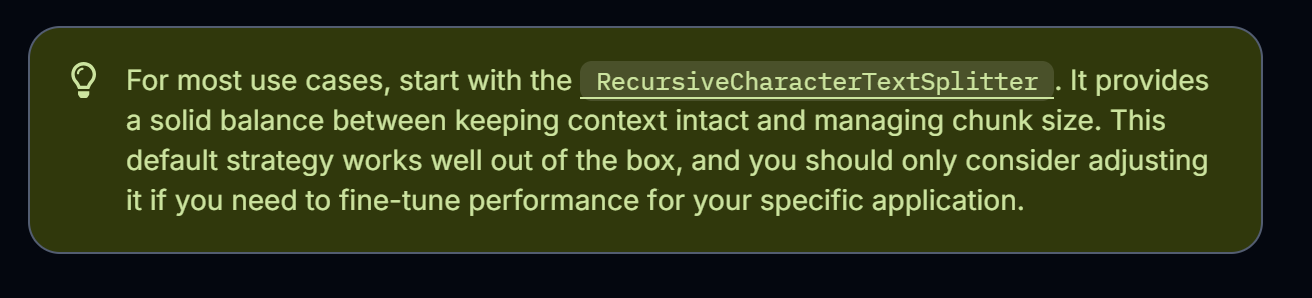

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


# Initialize the splitter with configuration

splitter = RecursiveCharacterTextSplitter(
    # Maximum characters per chunk
    chunk_size=1000,

    # Overlap between chunks for context continuity
    chunk_overlap=200,

    # Function to measure chunk length (default is len())
    # Use tiktoken for token-based splitting with LLMs
    length_function=len,

    # Whether to include each chunk's start index in metadata
    add_start_index=True,

    # Custom separator hierarchy
    separators=["\n\n", "\n", ". ", " ", ""]
)

# Example document
document = """
# Introduction to Machine Learning

Machine learning is a subset of artificial intelligence that enables systems to learn from data.

## Supervised Learning

Supervised learning uses labeled datasets to train algorithms. The model learns to map inputs to outputs.

### Classification

Classification predicts categorical labels. Common algorithms include:
- Logistic Regression
- Decision Trees
- Support Vector Machines

### Regression

Regression predicts continuous values. Examples include:
- Linear Regression
- Polynomial Regression
- Random Forest Regression

## Unsupervised Learning

Unsupervised learning finds patterns in unlabeled data.

### Clustering

Clustering groups similar data points together. Popular methods:
- K-Means
- DBSCAN
- Hierarchical Clustering
"""

# Split the document
chunks = splitter.split_text(document)

# Examine results
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i + 1} ({len(chunk)} chars) ---")
    print(chunk[:200] + "..." if len(chunk) > 200 else chunk)
    print()

--- Chunk 1 (775 chars) ---
# Introduction to Machine Learning

Machine learning is a subset of artificial intelligence that enables systems to learn from data.

## Supervised Learning

Supervised learning uses labeled datasets ...



# Step 13: Metadata filtering (widely used in prod)


Some examples of metadata

document_name, page, chapter, year, department, topic, document_type
aws_guide.pdf, 1, Introduction, 2025, Engineering, Overview, Manual
aws_guide.pdf, 12, Amazon S3, 2025, Engineering, Storage, Documentation
aws_guide.pdf, 24, Amazon SQS, 2025, Engineering, Messaging, Documentation
aws_guide.pdf, 38, AWS Lambda, 2024, Engineering, Compute, Documentation
hr_policy.pdf, 5, Leave Policy, 2025, HR, Leave, Policy
hr_policy.pdf, 12, Employee Benefits, 2024, HR, Benefits, Policy
finance_report.pdf, 8, Revenue, 2025, Finance, Revenue, Report
finance_report.pdf, 15, Expenses, 2025, Finance, Expenses, Report

In [ ]:
documents_with_filters = [
    {
        "text": """
        Amazon S3 is an object storage service designed for storing
        and retrieving files. It provides high durability and is
        commonly used for backups, static websites, data lakes,
        and application assets.
        """,
        "metadata": {
            "department": "Engineering",
            "year": 2025,
            "topic": "Storage"
        }
    },

    {
        "text": """
        Amazon SQS is a managed message queue service.
        It allows applications to communicate asynchronously.
        Producers send messages to a queue and consumers process
        those messages independently.
        """,
        "metadata": {
            "department": "Engineering",
            "year": 2025,
            "topic": "Messaging"
        }
    },

    {
        "text": """
        AWS Lambda is a serverless compute service.
        Developers upload code and AWS executes the code in response
        to events. Lambda automatically manages servers and scales
        applications based on incoming requests.
        """,
        "metadata": {
            "department": "Engineering",
            "year": 2024,
            "topic": "Compute"
        }
    },

    {
        "text": """
        Amazon DynamoDB is a managed NoSQL database.
        It provides low-latency access to data and automatically
        scales to handle large workloads.
        """,
        "metadata": {
            "department": "Engineering",
            "year": 2024,
            "topic": "Database"
        }
    },

    {
        "text": """
        Employees can request annual leave through the company
        HR portal. Managers should review leave requests within
        three working days.
        """,
        "metadata": {
            "department": "HR",
            "year": 2025,
            "topic": "Leave Policy"
        }
    },

    {
        "text": """
        The company provides employees with health insurance
        coverage. Employees can add eligible dependents during
        the annual enrollment period.
        """,
        "metadata": {
            "department": "HR",
            "year": 2024,
            "topic": "Benefits"
        }
    }
]

In [ ]:
metadata_filter = {
    "department": "HR",
    "year": 2025
}

# Step 14: Corrective RAG (CRAG)


In [ ]:
def evaluate_retrieval(question, results):

    context = "\n\n".join(
        result["text"]
        for result in results
    )

    prompt = f"""
You are evaluating whether retrieved documents are useful for answering
a user's question. It could be only one sentence that's relevant, it is still relevant.

Question:
{question}

Retrieved documents:
{context}

Return ONLY one of these:
RELEVANT
NOT_RELEVANT

Are the retrieved documents relevant enough to answer the question?
"""

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {
                "role": "system",
                "content": "You evaluate retrieval quality."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_completion_tokens=50,
        reasoning_effort="low",
        temperature=0
    )

    return response.choices[0].message.content.strip()

In [ ]:
def corrective_rag(question):

    # 1. Retrieve
    results = hybrid_search(
        question,
        top_k=5
    )

    # 2. Rerank
    results = rerank(
        question,
        results,
        top_k=3
    )

    # 3. Evaluate retrieval
    evaluation = evaluate_retrieval(
        question,
        results
    )

    print("Retrieval:", evaluation)

    # 4. Correct if retrieval is poor
    if "NOT_RELEVANT" in evaluation:

        print("Correcting retrieval...")

        rewritten_query = rewrite_query(question)

        results = hybrid_search(
            rewritten_query,
            top_k=5
        )

        results = rerank(
            rewritten_query,
            results,
            top_k=3
        )

    # 5. Return retrieved context
    return results

In [ ]:
documents = [
    """
    Amazon SQS is a managed message queue service.

    It allows applications to communicate asynchronously.
    Producers send messages to a queue and consumers process
    those messages independently.

    SQS is commonly used to decouple distributed applications
    so that one service does not have to wait for another service
    to finish processing.
    """,

    """
    AWS Lambda is a serverless compute service.

    Developers upload code and AWS executes the code in response
    to events. Lambda automatically manages servers and scales
    applications based on incoming requests.
    """,

    """
    Amazon S3 is an object storage service designed for storing
    and retrieving files.

    It is commonly used for backups, static websites, data lakes,
    application assets, and large collections of unstructured data.
    """,

    """
    Amazon DynamoDB is a managed NoSQL database.

    It provides low-latency access to data and automatically
    scales to handle large workloads.

    DynamoDB is commonly used for applications that require
    fast access to large amounts of structured data.
    """,

    """
    Amazon API Gateway is a managed service for creating,
    publishing, monitoring, and securing APIs.

    It can route incoming HTTP requests to backend services
    such as AWS Lambda.
    """,

    """
    Amazon SNS is a publish-subscribe messaging service.

    It allows applications to send notifications to multiple
    subscribers or downstream systems.

    SNS is commonly used for event broadcasting and notifications.
    """,

    """
    AWS CloudWatch provides monitoring and observability for
    AWS resources and applications.

    It collects metrics, logs, and events and can trigger
    alarms when specified conditions occur.
    """,

    """
    AWS IAM manages access to AWS resources.

    It allows administrators to define users, roles, policies,
    and permissions controlling which resources applications
    and users can access.
    """
]
# Now, call the new function to process the current documents
chunks, chunk_embeddings, bm25 = process_documents(documents, embedding_model)

results = corrective_rag(
    "How can I make two services work independently so one doesn't have to wait for the other?"
)

for result in results:
    print(result["text"])
    print()

Retrieval: RELEVANT
Amazon SQS is a managed message queue service. It allows applications to communicate asynchronously. Producers send messages to a queue and consumers process those messages independently. SQS is commonly used to decouple distributed applications so that one service does not have to wait for another service to finish processing.

Amazon API Gateway is a managed service for creating, publishing, monitoring, and securing APIs. It can route incoming HTTP requests to backend services such as AWS Lambda.

AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages servers and scales applications based on incoming requests.



In [ ]:
results = corrective_rag(
    "Why is sky blue?"
)

for result in results:
    print(result["text"])
    print()

Retrieval: NOT_RELEVANT
Correcting retrieval...
Amazon S3 is an object storage service designed for storing and retrieving files. It is commonly used for backups, static websites, data lakes, application assets, and large collections of unstructured data.

Amazon SNS is a publish-subscribe messaging service. It allows applications to send notifications to multiple subscribers or downstream systems. SNS is commonly used for event broadcasting and notifications.

AWS Lambda is a serverless compute service. Developers upload code and AWS executes the code in response to events. Lambda automatically manages servers and scales applications based on incoming requests.



# Adaptive RAG
### Routing

Question ---> Router --->RAG or Direct

In [ ]:
def route_question(question):

    knowledge_base = """
    Our knowledge base contains information about AWS services,
    including Amazon S3, Amazon SQS, AWS Lambda, Amazon DynamoDB,
    Amazon API Gateway, Amazon SNS, and AWS IAM.
    """

    prompt = f"""
You are a query router.

Decide whether the user's question should be answered using
the knowledge base or directly by the LLM.

Knowledge base:
{knowledge_base}

Return ONLY:
RAG
or
DIRECT

Use RAG if the question is about information covered by the
knowledge base.

Use DIRECT if the question is unrelated to the knowledge base.

Question:
{question}
"""

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {
                "role": "system",
                "content": "You are a query routing classifier."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=20,
        temperature=0
    )

    return response.choices[0].message.content.strip()

In [ ]:
def adaptive_rag(question):

    route = route_question(question)

    print("Route:", route)

    if "DIRECT" in route:
        prompt = question

    else:
        results = hybrid_search(
            question,
            top_k=5
        )

        results = rerank(
            question,
            results,
            top_k=3
        )

        context = "\n\n".join(
            result["text"]
            for result in results
        )

        prompt = f"""
Answer the question using the provided context.

Context:
{context}

Question:
{question}
"""

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_completion_tokens=300,
        reasoning_effort="low",
        temperature=0
    )

    return response.choices[0].message

In [ ]:
questions = [
    "What is AWS SQS?",
    "What is the capital of France?",
    "How does Lambda handle incoming requests?",
    "What is 25 multiplied by 4?"
]

for question in questions:

    print("\nQuestion:", question)

    answer = adaptive_rag(question)

    print("Answer:", answer)


Question: What is AWS SQS?
Route: RAG
Answer: ChatCompletionMessage(content='AWS SQS (Simple Queue Service) is a managed message queue service provided by Amazon Web Services (AWS). It allows applications to communicate asynchronously by enabling producers to send messages to a queue and consumers to process those messages independently. This decouples distributed applications, allowing one service to continue processing without waiting for another service to finish.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[])

Question: What is the capital of France?
Route: DIRECT
Answer: ChatCompletionMessage(content='The capital of France is Paris.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[])

Question: How does Lambda handle incoming requests?
Route: RAG
Answer: ChatCompletionMessage(content='According to the provided context, AWS Lambda automatically manages servers and scales applications

#Agentic RAG - ReAct ---> Reasoning + Act

Question → Agent → Search → Evaluate → Search Again? → Evaluate → Answer

In [ ]:
def agentic_rag(question, max_steps=3):

    conversation = [
        {
            "role": "system",
            "content": """
You are a RAG agent.

You have access to a knowledge base through the SEARCH action.

For each step, decide what to do.

Return exactly one of:

SEARCH: <search query>
ANSWER: <final answer>

Use SEARCH when you need information from the knowledge base.
Use ANSWER when you have enough information to answer the question.
"""
        },
        {
            "role": "user",
            "content": question
        }
    ]

    for step in range(max_steps):

        response = client.chat.completions.create(
            model="meta-llama/Llama-3.1-8B-Instruct",
            messages=conversation,
            max_tokens=200,
            temperature=0
        )

        decision = response.choices[0].message.content.strip()

        print(f"\nStep {step + 1}:")
        print(decision)

        # Agent wants to search
        if decision.startswith("SEARCH:"):

            search_query = decision.replace(
                "SEARCH:", ""
            ).strip()

            results = hybrid_search(
                search_query,
                top_k=5
            )

            results = rerank(
                search_query,
                results,
                top_k=3
            )

            context = "\n\n".join(
                result["text"]
                for result in results
            )

            conversation.append({
                "role": "assistant",
                "content": decision
            })

            conversation.append({
                "role": "user",
                "content": f"""
Search results:

{context}

Decide whether you have enough information.
If not, search again.
"""
            })

        # Agent has enough information
        elif decision.startswith("ANSWER:"):

            return decision.replace(
                "ANSWER:",
                ""
            ).strip()

    return "I could not find enough information."

In [ ]:
question = """
How can AWS services communicate asynchronously
without requiring one service to wait for another?
"""

answer = agentic_rag(question)

print("\nFinal Answer:")
print(answer)


Step 1:
SEARCH: asynchronous communication in AWS services

Step 2:
SEARCH: AWS services asynchronous communication without waiting for another service

Step 3:
SEARCH: AWS services asynchronous communication example

Final Answer:
I could not find enough information.


In [ ]:
def agentic_rag(question, max_steps=3, llm_model_name="meta-llama/Llama-3.1-8B-Instruct"):

    messages = [
        {
    "role": "system",
    "content": """
You are a RAG agent.

You can search a knowledge base.

IMPORTANT:
You may ONLY use facts explicitly stated in the search results.
Do not use your own knowledge.
Do not add facts that are not present in the search results.

After seeing search results:

If the results contain enough information:
ANSWER: <answer>

If information is missing:
SEARCH: <new search query>

Do not search again if the answer can be supported by the results.
Do not repeat a previous search query.
"""
},
        {
            "role": "user",
            "content": question
        }
    ]

    previous_queries = []

    for step in range(max_steps):

        response = client.chat.completions.create(
            model=llm_model_name,
            messages=messages,
            max_tokens=200,
            temperature=0
        )

        decision = response.choices[0].message.content.strip()
        print(decision)

        print(f"Step {step + 1}: {decision}")

        # -------------------------
        # Agent wants to answer
        # -------------------------
        if decision.startswith("ANSWER:"):

            return decision.replace(
                "ANSWER:",
                ""
            ).strip()

        # -------------------------
        # Agent wants to search
        # -------------------------
        if decision.startswith("SEARCH:"):

            search_query = decision.replace(
                "SEARCH:",
                ""
            ).strip()

            # Prevent repeated searches
            if search_query.lower() in [
                q.lower() for q in previous_queries
            ]:
                return "The agent could not find enough information."

            previous_queries.append(search_query)

            results = hybrid_search(
                search_query,
                top_k=5
            )

            results = rerank(
                search_query,
                results,
                top_k=3
            )

            context = "\n\n".join(
                result["text"]
                for result in results
            )

            messages.append({
                "role": "assistant",
                "content": decision
            })

            messages.append({
                "role": "user",
                "content": f"""
Search results for:

{search_query}

{context}

Now decide:

ANSWER: <answer>

or

SEARCH: <different search query>
"""
            })

    return "The agent could not find enough information."

In [ ]:
llm_model_name="meta-llama/Llama-3.1-8B-Instruct"

question = """
How can AWS services communicate asynchronously without requiring one service to wait for another?
"""
answer = agentic_rag(question, llm_model_name=llm_model_name)

print("\nFinal Answer:")
print(answer)

SEARCH: AWS asynchronous communication without waiting for another service
Step 1: SEARCH: AWS asynchronous communication without waiting for another service
ANSWER: AWS services can communicate asynchronously without requiring one service to wait for another by using Amazon SQS, AWS Lambda, and Amazon API Gateway. Amazon SQS allows producers to send messages to a queue and consumers to process those messages independently, decoupling distributed applications. AWS Lambda can be triggered by events and automatically scales applications based on incoming requests. Amazon API Gateway can route incoming HTTP requests to backend services such as AWS Lambda, enabling asynchronous communication between services.
Step 2: ANSWER: AWS services can communicate asynchronously without requiring one service to wait for another by using Amazon SQS, AWS Lambda, and Amazon API Gateway. Amazon SQS allows producers to send messages to a queue and consumers to process those messages independently, decoupl

In [ ]:
{
    "role": "system",
    "content": """
You are a RAG agent.

You can search a knowledge base.

After seeing search results:

- If the results contain enough information to answer the question,
  return:
  ANSWER: <answer>

- If information is missing, return:
  SEARCH: <new search query>

Rules:
- Use ONLY information supported by the search results.
- Do not add outside knowledge.
- Do not make assumptions.
- Do not repeat a previous search query.
"""
}

{'role': 'system',
 'content': '\nYou are a RAG agent.\n\nYou can search a knowledge base.\n\nAfter seeing search results:\n\n- If the results contain enough information to answer the question,\n  return:\n  ANSWER: <answer>\n\n- If information is missing, return:\n  SEARCH: <new search query>\n\nRules:\n- Use ONLY information supported by the search results.\n- Do not add outside knowledge.\n- Do not make assumptions.\n- Do not repeat a previous search query.\n'}